<h1><span style="color:black; font-weight:bold"><u><center>Rocket League Data Exploration/Visualization</center></u></span></h1>

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from matplotlib.animation import FuncAnimation
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import hdbscan
import math
import os

In [2]:
os.environ["LOKY_MAX_CPU_COUNT"] = '14'
os.environ["OMP_NUM_THREADS"] = "1"

<p><span style="color:green; font-weight:bold">Data is inputted and merged into general skill categories. The data is filtered for only numeric columns for the purpose of dimensionality reduction and clustering.</span></p>

In [3]:
bronze = pd.read_csv("processed_csvs/bronze.csv")
champion = pd.read_csv("processed_csvs/champion.csv")
diamond = pd.read_csv("processed_csvs/diamond.csv")
gold = pd.read_csv("processed_csvs/gold.csv")
grand = pd.read_csv("processed_csvs/grand.csv")
platinum = pd.read_csv("processed_csvs/platinum.csv")
silver = pd.read_csv("processed_csvs/silver.csv")
supersonic = pd.read_csv("processed_csvs/supersonic.csv")

ranks = {"Bronze": bronze, "Champion": champion, "Diamond": diamond, "Gold": gold, "Grandchampion": grand, 
         "Platinum": platinum, "Silver": silver, "Supersonic": supersonic}

low = pd.concat([bronze, silver, gold], ignore_index=True)
intermediate = pd.concat([platinum, diamond, champion], ignore_index=True)
high = pd.concat([grand, supersonic], ignore_index=True)

rank_levels = {'Low': low, 'Intermediate': intermediate, 'High': high}

In [4]:
ranks['Bronze'].columns

Index(['color', 'player name', 'platform', 'player id', 'car id', 'car name',
       'game duration', 'score', 'goals', 'assists', 'saves', 'shots',
       'shots conceded', 'goals conceded',
       'goals conceded while last defender', 'shooting percentage', 'bpm',
       'avg boost amount', 'amount collected', 'amount collected big pads',
       'amount collected small pads', 'count collected big pads',
       'count collected small pads', 'amount stolen', 'amount stolen big pads',
       'amount stolen small pads', 'count stolen big pads',
       'count stolen small pads', '0 boost time', '100 boost time',
       'amount used while supersonic', 'amount overfill total',
       'amount overfill stolen', 'avg speed', 'total distance',
       'time slow speed', 'percentage slow speed', 'time boost speed',
       'percentage boost speed', 'time supersonic speed',
       'percentage supersonic speed', 'time on ground', 'percentage on ground',
       'time low in air', 'percentage low in a

In [5]:
for rank, df in rank_levels.items():
    rank_levels[rank] = df.dropna()

rank_sne = {}

for rank, df in rank_levels.items():
    temp = df.drop(columns=[
    'color','player name','platform','player id','car id','car name','rank'])
    rank_sne[rank] = temp

for rank, df in rank_sne.items():
    check = df.var().sort_values()
    for j in check.index:
        if check[j] == 0:
            print(j)

for rank, df in rank_sne.items():
    print(df.isna().sum().sort_values())

game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third  

<h3><span style="color:blue; font-weight:bold">Initial PCA and t-SNE Analysis</span></h3>
<p><span style="color:green; font-weight:bold">An initial run of PCA and t-SNE is ran to get an initial sense of the data behavior. PCA variance analysis is first ran to analyze a good range of component number that covers enough variance for the data. 18 is determined to cover about 90% of variance and is then used to transform the fit of t-SNE. Each skill group is fit to its own PCA and used for its individual run of t-SNE.</span></p>

1 components: 0.3554
2 components: 0.4637
3 components: 0.5390
4 components: 0.5959
5 components: 0.6343
6 components: 0.6706
7 components: 0.7022
8 components: 0.7293
9 components: 0.7508
10 components: 0.7711
11 components: 0.7892
12 components: 0.8062
13 components: 0.8230
14 components: 0.8393
15 components: 0.8540
16 components: 0.8673
17 components: 0.8795
18 components: 0.8913
19 components: 0.9026
20 components: 0.9129
21 components: 0.9228
22 components: 0.9312
23 components: 0.9389
24 components: 0.9459
25 components: 0.9524
26 components: 0.9580
27 components: 0.9631
28 components: 0.9673
29 components: 0.9711
30 components: 0.9744
31 components: 0.9775
32 components: 0.9804
33 components: 0.9829
34 components: 0.9848
35 components: 0.9867
36 components: 0.9884
37 components: 0.9900
38 components: 0.9917
39 components: 0.9930
40 components: 0.9943
41 components: 0.9953
42 components: 0.9961
43 components: 0.9968
44 components: 0.9974
45 components: 0.9979
46 components: 0.99

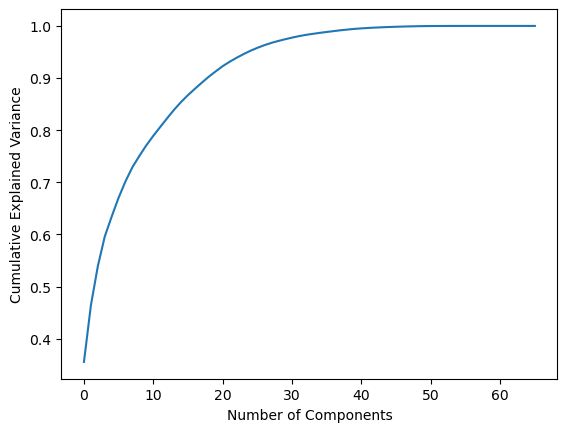

In [6]:
scaler = StandardScaler()
rank_scaled = scaler.fit_transform(rank_sne['Low'])

pca = PCA()
pca.fit(rank_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
cum_var = np.cumsum(pca.explained_variance_ratio_)
for i, val in enumerate(np.cumsum(pca.explained_variance_ratio_), start=1):
    print(f"{i} components: {val:.4f}")

In [7]:
tsne_data = {}

for rank, df in rank_sne.items():
    scaler = StandardScaler()
    rank_scaled = scaler.fit_transform(df)

    rank_pca = PCA(n_components=18).fit_transform(rank_scaled)
    rank_tsne = TSNE(n_components=2, random_state=42).fit_transform(rank_pca)

    tsne_data[rank] = [rank_pca,rank_tsne]

<p><span style="color:green; font-weight:bold">The following visualizations represent the t-SNE dimensionality in a 2D space at a default perplexity parameter value. From the initial visuals you can see some clustering structure in each skill group from a visual point of view. Further validation will be done to determine a proper perplexity value.</span></p>

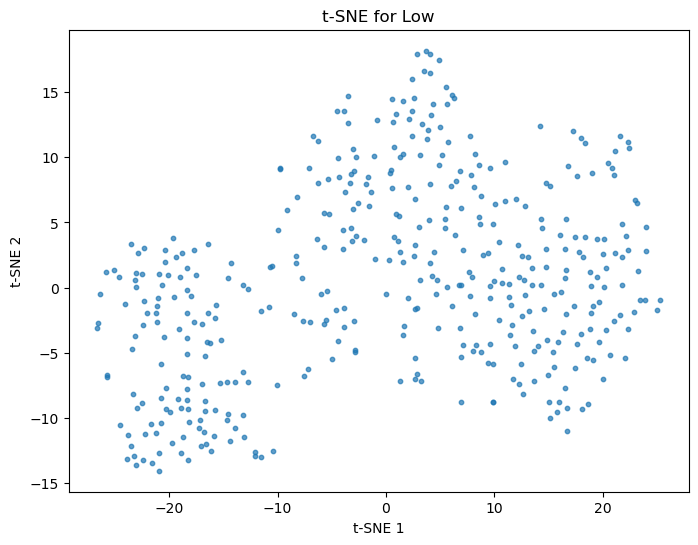

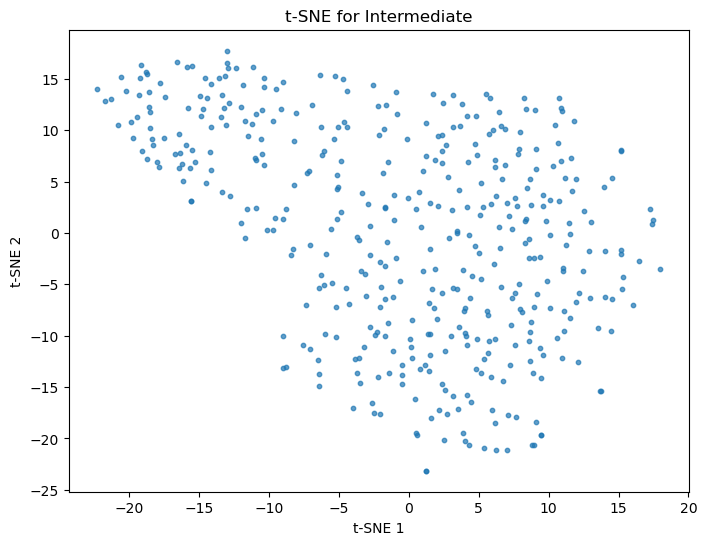

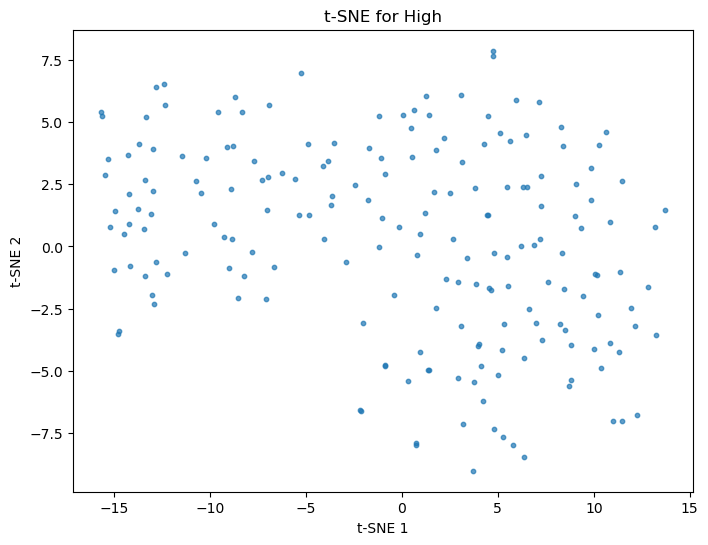

In [8]:
for rank, coords in tsne_data.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[1][:, 0], coords[1][:, 1], s=10, alpha=0.7)
    plt.title(f"t-SNE for {rank}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

<p><span style="color:green; font-weight:bold">Below are just some evaluation scores for the t-SNE reduction and an initial clustering run.</span></p>

In [9]:
for rank, coords, in tsne_data.items():
    
    score = trustworthiness(coords[0], coords[1], n_neighbors=5)
    print(f'{rank} trustworthiness: {score}')

Low trustworthiness: 0.9567464170134073
Intermediate trustworthiness: 0.9504327871492411
High trustworthiness: 0.9306329257246377


In [10]:
for rank, coords, in tsne_data.items():
    labels = KMeans(n_clusters=5).fit_predict(coords[1])
    sil = silhouette_score(coords[1], labels)
    print(f'{rank} silhoutte score: {sil}')

Low silhoutte score: 0.4115104377269745
Intermediate silhoutte score: 0.3982139229774475
High silhoutte score: 0.3946352005004883


C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<p><span style="color:green; font-weight:bold">6 perplexity values are cross-validated and visualized on a grid to  determine if a specific value can give clearer clustering visibility. The three skill groups are plotted on the same plot for each perplexity value, for both simplicity and to visualize differentiation between skill groups.</span></p>

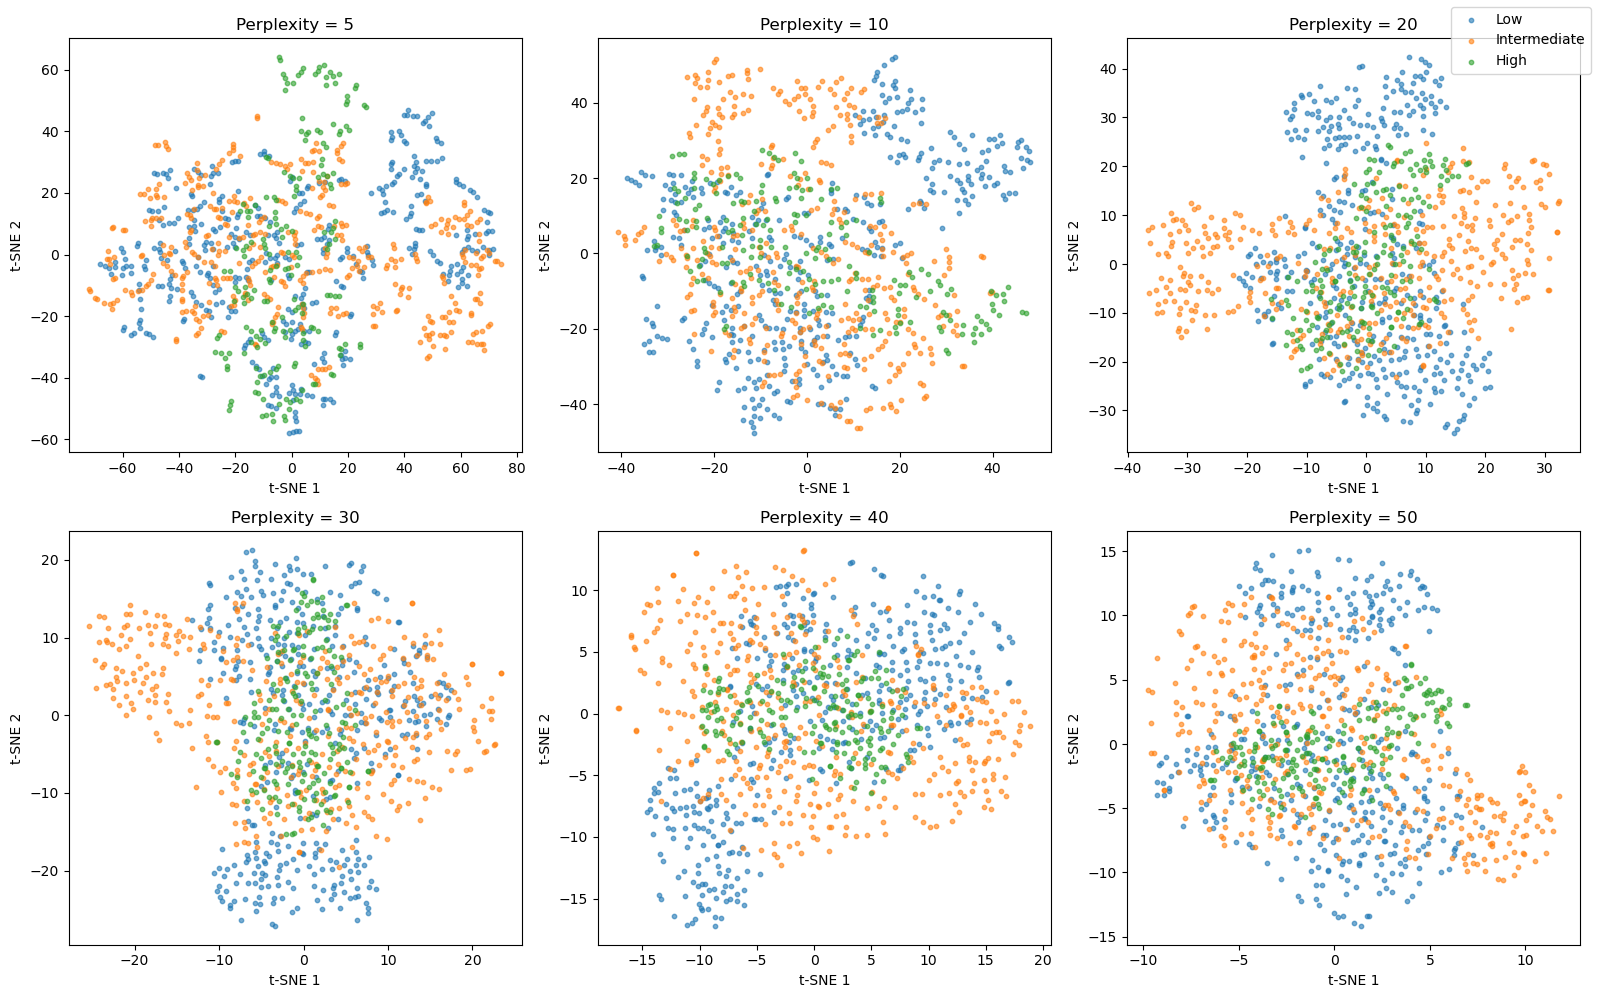

In [11]:
# Perplexity values
perplexities = [5, 10, 20, 30, 40, 50]

cols = 3
rows = math.ceil(len(perplexities) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for ax, p in zip(axes, perplexities):

    for rank, df in rank_sne.items():
        X = df.select_dtypes(include="number")

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        coords = TSNE(
            n_components=2,
            perplexity=p,
            random_state=42
        ).fit_transform(X_scaled)

        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            label=rank,
            s=10,
            alpha=0.6
        )

    ax.set_title(f"Perplexity = {p}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

for ax in axes[len(perplexities):]:
    ax.axis("off")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right")

plt.tight_layout()
plt.show()

<h3><span style="color:blue; font-weight:bold">3D t-SNE Visualizations</span></h3>
<p><span style="color:green; font-weight:bold">3D renderings of each skill level's t-SNE structure is produced. It was determined from the previous grid that 20-30 perplexity would be fit for all skill levels.</span></p>

<p><span style="color:green; font-weight:bold">The first plot is the combination of all ranks' t-SNE onto one plot. This is to get a 3D understanding of how the data behaves next to each other, although each t-SNE is calculated relative to its respective skill data.</span></p>

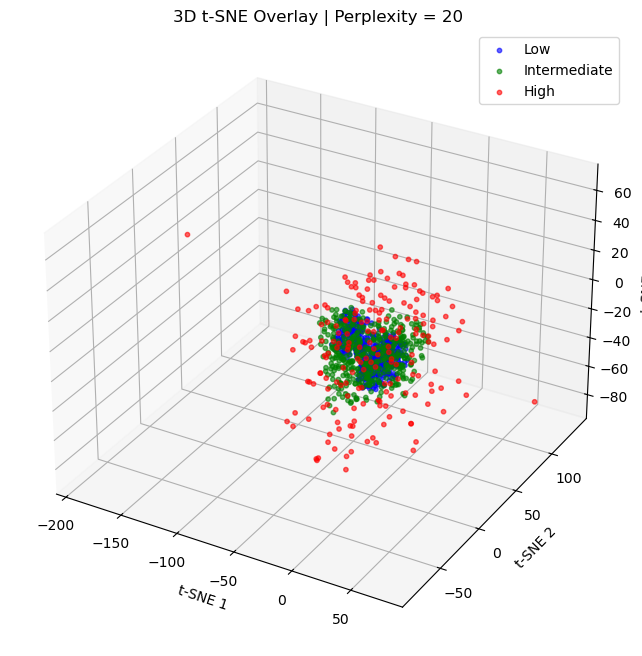

In [31]:
p = 20

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

colors = {
    "Low": "blue",
    "Intermediate": "green",
    "High": "red"
}

for rank, df in rank_sne.items():

    X = df.select_dtypes(include="number")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    coords = TSNE(n_components=3,perplexity=p,random_state=42).fit_transform(X_scaled)

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        color=colors.get(rank, "black"),
        label=rank,
        s=10,
        alpha=0.6
    )

ax.set_title(f"3D t-SNE Overlay | Perplexity = {p}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
ax.legend()

plt.show()

<p><span style="color:green; font-weight:bold">The following will be individual plots for each rank's t-SNE. What will be included is a flat 3D rendering of the data as well as a rotatable plot (only in notebook). What can be seen from these 3D renderings is that their is minimal clustering visibility. This is likely due to the continous, complex nature of the numeric data we are working with.</span></p>

<p><span style="color:green; font-weight:bold">Traditional clustering techniques such as KMeans or DBScan, are likely not to produce natural clustering identifications. What is opted towards instead, is using Local Outlier Factor which detects "anomalies" based on density-neighboring calculations. Essentially, each point's nearest neighbors' are summed up for their distances from the point (its reachability) and averaged to determine the density of each point. Depending on the density score, the point is identified as an outlier.</span></p>

Local Outlier Factor (LOF): https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html

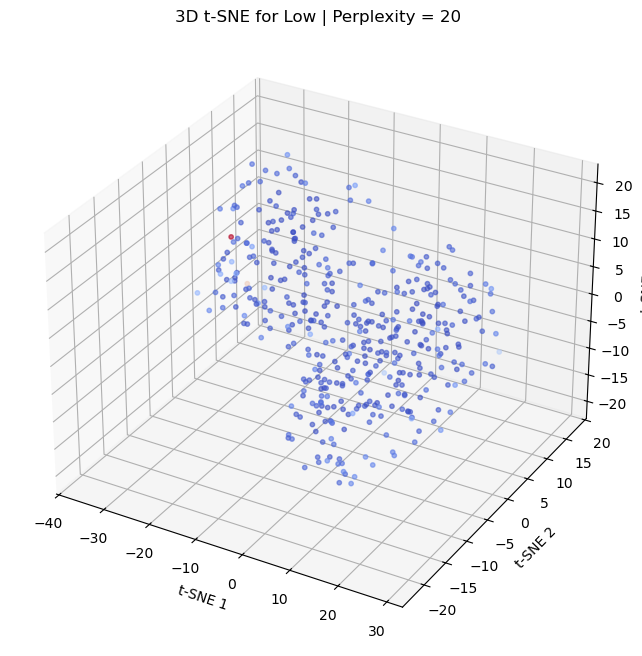

In [15]:
p = 20
scaler = StandardScaler()
low_scaled = scaler.fit_transform(rank_sne['Low'])
coords_low = TSNE(n_components=3, perplexity=p, random_state=42).fit_transform(low_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
scores = -lof.fit_predict(low_scaled)
outlier_score = -lof.negative_outlier_factor_

low_df = rank_sne['Low'].copy()
low_df["lof_score"] = outlier_score

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    coords_low[:, 0],
    coords_low[:, 1],
    coords_low[:, 2],
    c=outlier_score,
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

ax.set_title(f"3D t-SNE for Low | Perplexity = {p}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.show()

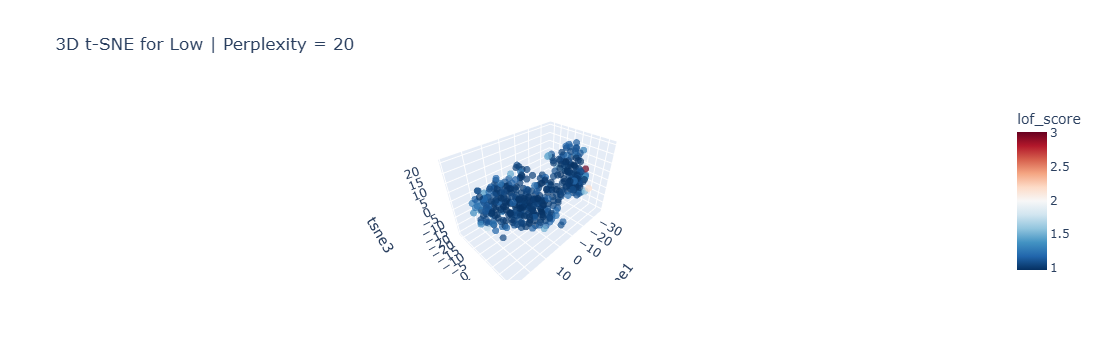

In [34]:
p = 20

low_df = rank_sne["Low"].copy()
low_X = low_df.select_dtypes(include="number")

scaler = StandardScaler()
low_scaled = scaler.fit_transform(low_X)

coords_low = TSNE(n_components=3,perplexity=p,random_state=42).fit_transform(low_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit(low_scaled)
outlier_score = -lof.negative_outlier_factor_

plot_df = pd.DataFrame(coords_low, columns=["tsne1", "tsne2", "tsne3"])
plot_df["lof_score"] = outlier_score

fig = px.scatter_3d(
    plot_df,
    x="tsne1",
    y="tsne2",
    z="tsne3",
    color="lof_score",
    color_continuous_scale="RdBu_r",
    opacity=0.7,
    hover_data=["lof_score"],
    title=f"3D t-SNE for Low | Perplexity = {p}"
)

fig.update_traces(marker=dict(size=4))
fig.show()

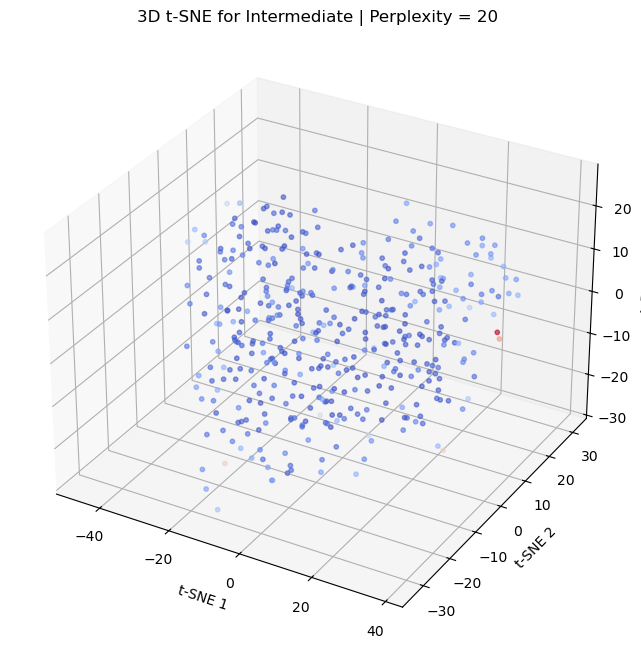

In [16]:
p = 20
scaler = StandardScaler()
inter_scaled = scaler.fit_transform(rank_sne['Intermediate'])
coords_inter = TSNE(n_components=3, perplexity=p, random_state=42).fit_transform(inter_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
scores = -lof.fit_predict(inter_scaled)
outlier_score = -lof.negative_outlier_factor_

inter_df = rank_sne['Intermediate'].copy()
inter_df["lof_score"] = outlier_score

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    coords_inter[:, 0],
    coords_inter[:, 1],
    coords_inter[:, 2],
    c=outlier_score,
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

ax.set_title(f"3D t-SNE for Intermediate | Perplexity = {p}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.show()

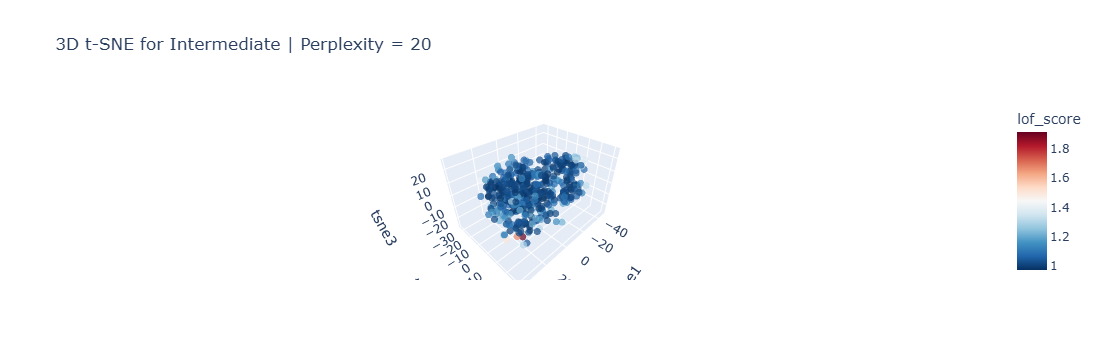

In [35]:
p = 20

inter_df = rank_sne["Intermediate"].copy()
inter_X = inter_df.select_dtypes(include="number")

scaler = StandardScaler()
inter_scaled = scaler.fit_transform(inter_X)

coords_inter = TSNE(n_components=3,perplexity=p,random_state=42).fit_transform(inter_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit(inter_scaled)
outlier_score = -lof.negative_outlier_factor_

plot_df = pd.DataFrame(coords_inter, columns=["tsne1", "tsne2", "tsne3"])
plot_df["lof_score"] = outlier_score

fig = px.scatter_3d(
    plot_df,
    x="tsne1",
    y="tsne2",
    z="tsne3",
    color="lof_score",
    color_continuous_scale="RdBu_r",
    opacity=0.7,
    hover_data=["lof_score"],
    title=f"3D t-SNE for Intermediate | Perplexity = {p}"
)

fig.update_traces(marker=dict(size=4))
fig.show()

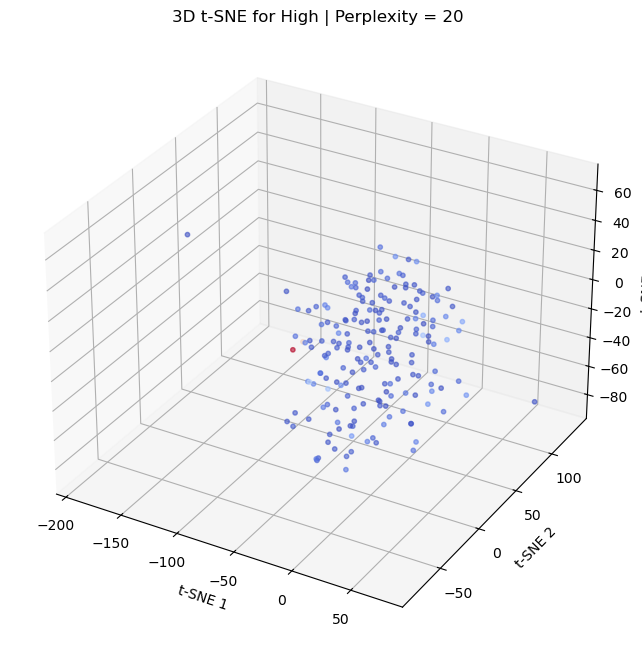

In [17]:
p = 20
scaler = StandardScaler()
high_scaled = scaler.fit_transform(rank_sne['High'])
coords_high = TSNE(n_components=3, perplexity=p, random_state=42).fit_transform(high_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
scores = -lof.fit_predict(high_scaled)
outlier_score = -lof.negative_outlier_factor_

high_df = rank_sne['High'].copy()
high_df["lof_score"] = outlier_score

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    coords_high[:, 0],
    coords_high[:, 1],
    coords_high[:, 2],
    c=outlier_score,
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

ax.set_title(f"3D t-SNE for High | Perplexity = {p}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.show()

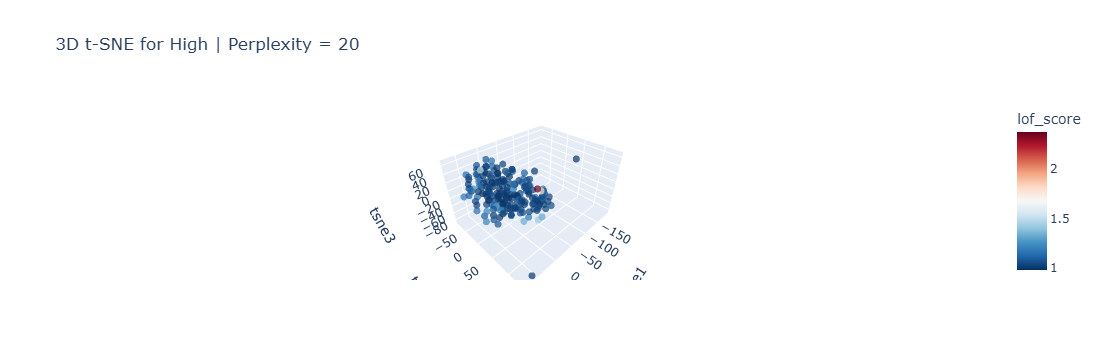

In [38]:
p = 20

high_df = rank_sne["High"].copy()
high_X = high_df.select_dtypes(include="number")

scaler = StandardScaler()
high_scaled = scaler.fit_transform(high_X)

coords_high = TSNE(n_components=3,perplexity=p,random_state=42).fit_transform(high_scaled)

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit(high_scaled)
outlier_score = -lof.negative_outlier_factor_

plot_df = pd.DataFrame(coords_high, columns=["tsne1", "tsne2", "tsne3"])
plot_df["lof_score"] = outlier_score

fig = px.scatter_3d(
    plot_df,
    x="tsne1",
    y="tsne2",
    z="tsne3",
    color="lof_score",
    color_continuous_scale="RdBu_r",
    opacity=0.7,
    hover_data=["lof_score"],
    title=f"3D t-SNE for High | Perplexity = {p}"
)

fig.update_traces(marker=dict(size=4))
fig.show()

<p><span style="color:green; font-weight:bold">The last 3D plot provided below is used to illustrate that even a complex clustering technique such as HDBScan, cannot find some moderate levels of clustering within one of the skill levels.</span></p>

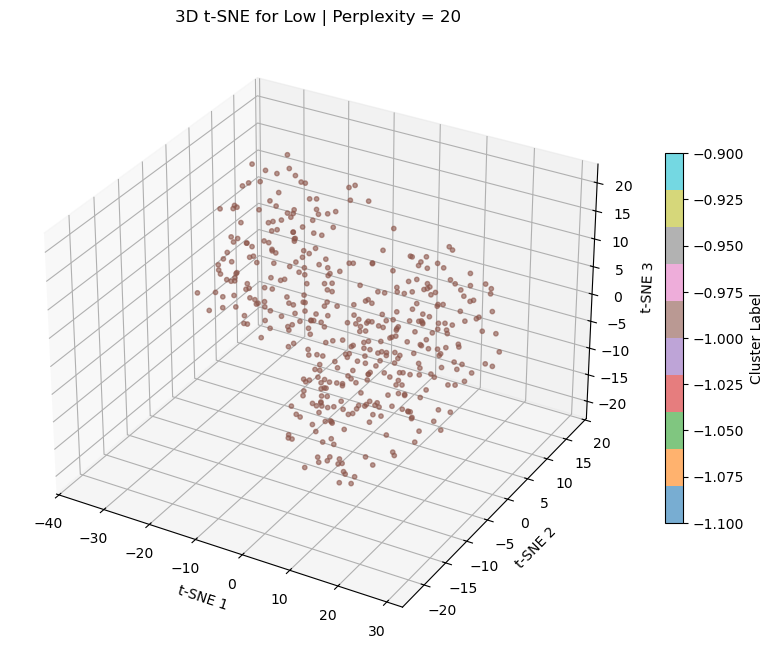

In [41]:
p = 20
scaler = StandardScaler()
low_scaled = scaler.fit_transform(rank_sne['Low'])
coords_low = TSNE(n_components=3, perplexity=p, random_state=42).fit_transform(low_scaled)

clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
hdb_cluster = clusterer.fit_predict(low_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    coords_low[:, 0],
    coords_low[:, 1],
    coords_low[:, 2],
    c=hdb_cluster,
    cmap="tab10",
    s=10,
    alpha=0.6
)

fig.colorbar(scatter, ax=ax, shrink=0.6, label="Cluster Label")

ax.set_title(f"3D t-SNE for Low | Perplexity = {p}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.show()

<h3><span style="color:blue; font-weight:bold">3D PCA Analysis</span></h3>
<p><span style="color:green; font-weight:bold">PCA dimensionality reduction is created for each skill level to determine if their is any meaninful clustering visibility within the PCA component space. First plotted, is 2D plots for the PCA of each skill group to get an initial scope of the data transformation. Followed are the 3D renderings of each PCA skill group. Each PCA dataset was then calculated for evidence of clustering using HDBScan. However, strength of any visible clustering was, again, weak in each skillgroup.</span></p>

In [42]:
rank_pca = {}

for rank, df in rank_sne.items():
    scaler = StandardScaler()
    rank_scaled = scaler.fit_transform(df)

    this_pca = PCA(n_components=18).fit_transform(rank_scaled)
    rank_pca[rank] = this_pca

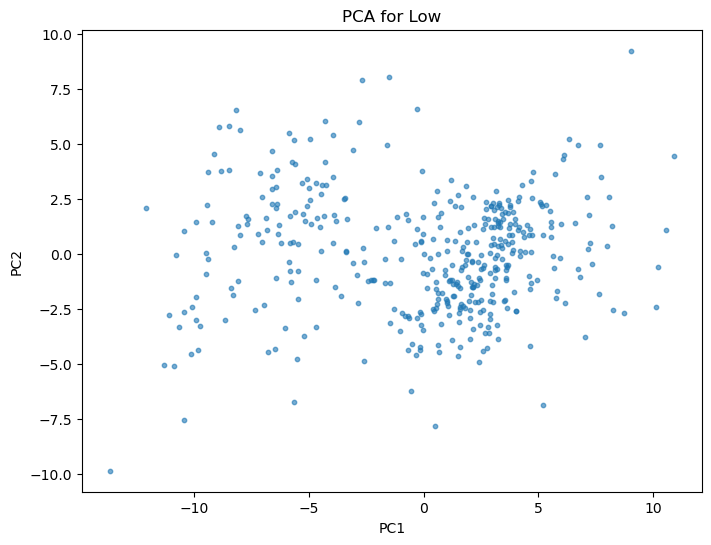

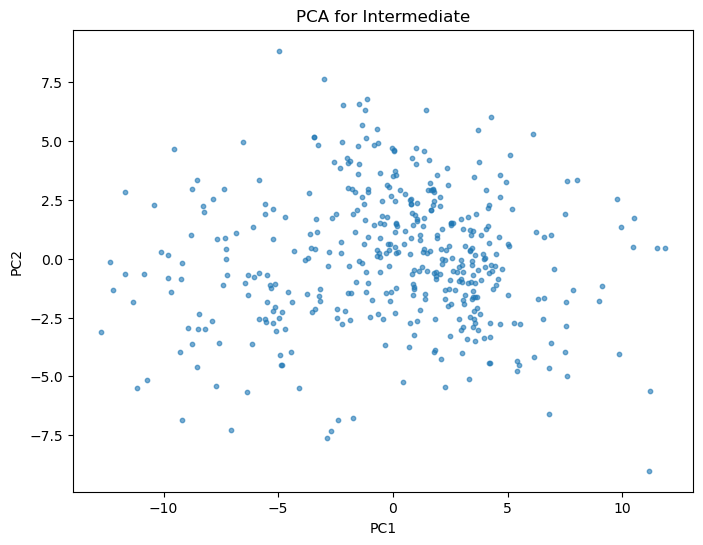

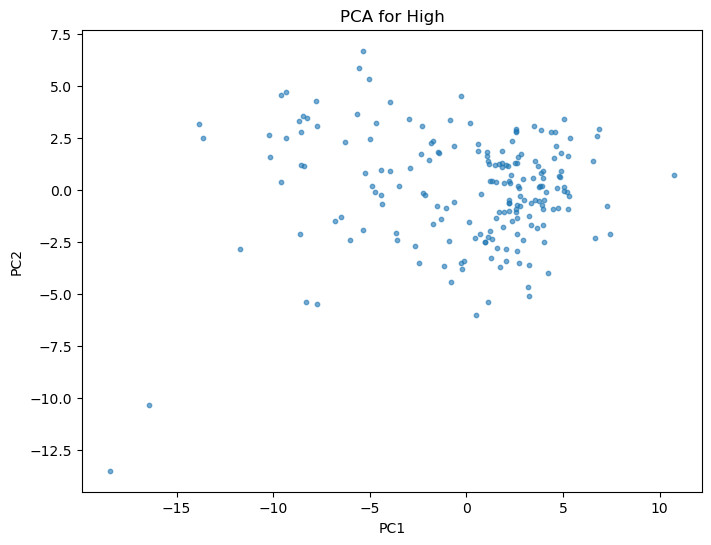

In [44]:
for rank, coords in rank_pca.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.6)
    plt.title(f"PCA for {rank}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

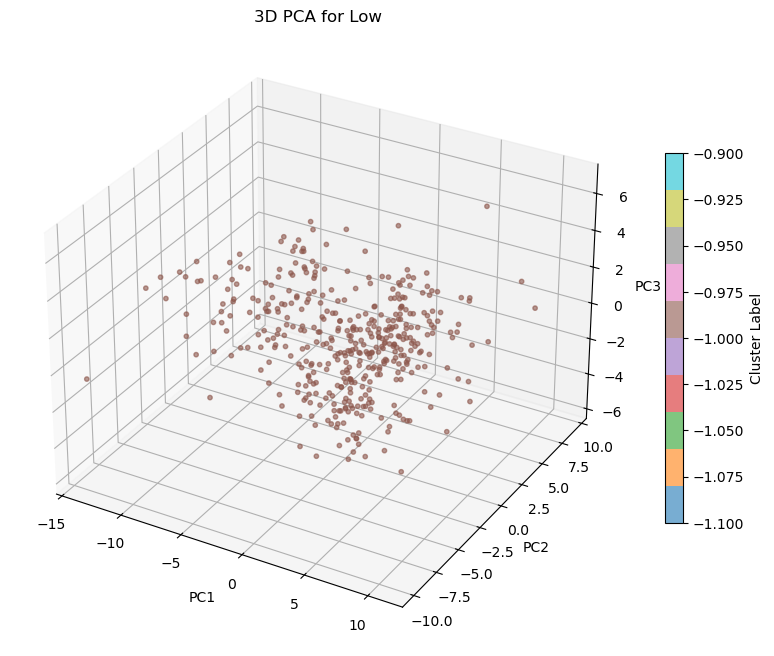

In [53]:
coords_low = rank_pca["Low"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
low_hdb = clusterer.fit_predict(rank_pca["Low"])

scatter = ax.scatter(coords_low[:, 0],
                     coords_low[:, 1],
                     coords_low[:, 2],
                     c=low_hdb,
                     cmap="tab10",
                     s=10, 
                     alpha=0.6)

fig.colorbar(scatter, ax=ax, shrink=0.6, label="Cluster Label")

ax.set_title(f"3D PCA for Low")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

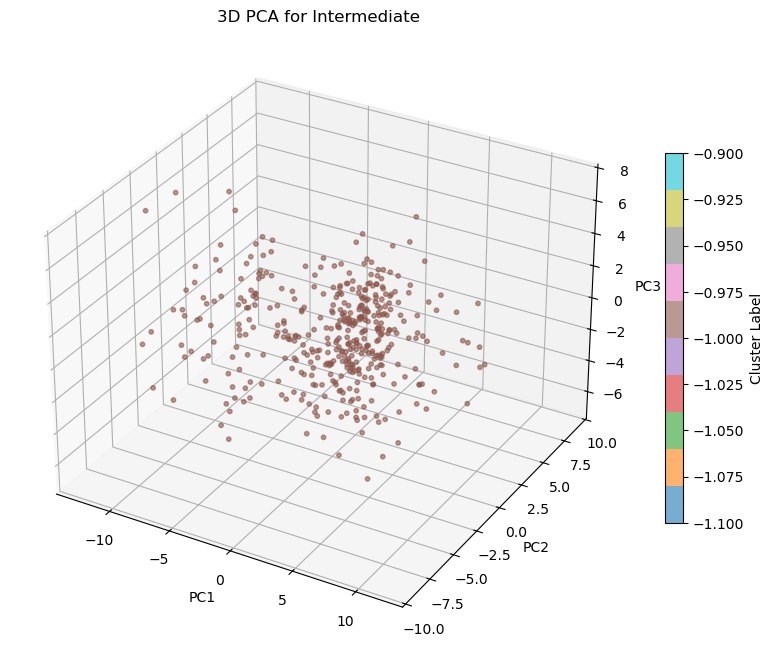

In [54]:
coords_inter = rank_pca["Intermediate"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
inter_hdb = clusterer.fit_predict(rank_pca["Intermediate"])

scatter = ax.scatter(coords_inter[:, 0],
                     coords_inter[:, 1],
                     coords_inter[:, 2],
                     c=inter_hdb,
                     cmap="tab10",
                     s=10, 
                     alpha=0.6)

fig.colorbar(scatter, ax=ax, shrink=0.6, label="Cluster Label")

ax.set_title(f"3D PCA for Intermediate")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

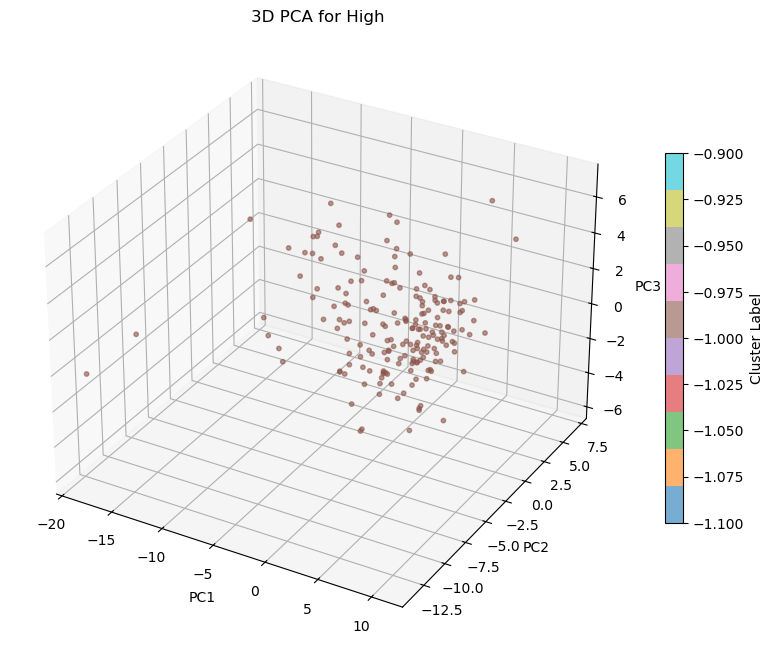

In [56]:
coords_high = rank_pca["High"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

clusterer = hdbscan.HDBSCAN(min_cluster_size=15)
high_hdb = clusterer.fit_predict(rank_pca["High"])

scatter = ax.scatter(coords_high[:, 0],
                     coords_high[:, 1],
                     coords_high[:, 2],
                     c=high_hdb,
                     cmap="tab10",
                     s=10, 
                     alpha=0.6)

fig.colorbar(scatter, ax=ax, shrink=0.6, label="Cluster Label")

ax.set_title(f"3D PCA for High")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()